# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [4]:
%pip install pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 17.4 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 8.2 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 7.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 7.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results.tsv", sep="\t")
df["val_bpb"] = pd.to_numeric(df["val_bpb"], errors="coerce")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df

Total experiments: 3
Columns: ['timestamp', 'val_bpb', 'training_seconds', 'total_seconds', 'peak_vram_mb', 'total_tokens_M', 'num_steps', 'num_params_M', 'depth', 'time_budget']


,timestamp,val_bpb,training_seconds,total_seconds,peak_vram_mb,total_tokens_M,num_steps,num_params_M,depth,time_budget
0,2026-03-18 01:46:32.353751,3.954539,7201.5,7228.9,7455.9,137.9,2104,5.2,4,7200
1,2026-03-18 07:25:11.007986,2.127223,301.7,325.2,7455.9,7.4,113,5.2,4,300
2,2026-03-23 00:51:36.435359,4.383176,18494.8,19617.8,7488.0,275.4,4203,5.2,4,18000


In [6]:
print("Experiment overview:")
print(f"  Date range:   {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"  Best val_bpb: {df['val_bpb'].min():.6f}  (run #{df['val_bpb'].idxmin()})")
print(f"  Worst:        {df['val_bpb'].max():.6f}")
print(f"  Mean:         {df['val_bpb'].mean():.6f}")
print()
print("Resource usage:")
print(f"  Avg training time:  {df['training_seconds'].mean()/3600:.1f} h  (total: {df['training_seconds'].sum()/3600:.1f} h)")
print(f"  Avg tokens trained: {df['total_tokens_M'].mean():.1f} M")
print(f"  Avg peak VRAM:      {df['peak_vram_mb'].mean():.0f} MB")

Experiment overview:
  Date range:   2026-03-18 → 2026-03-23
  Best val_bpb: 2.127223  (run #1)
  Worst:        4.383176
  Mean:         3.488313

Resource usage:
  Avg training time:  2.4 h  (total: 7.2 h)
  Avg tokens trained: 140.2 M
  Avg peak VRAM:      7467 MB


In [7]:
# All experiments sorted by val_bpb (best first)
ranked = df.sort_values("val_bpb").reset_index()
ranked.index += 1
print(f"{'Rank':>4}  {'val_bpb':>10}  {'train_h':>7}  {'tokens_M':>8}  {'steps':>6}  {'params_M':>8}  Timestamp")
print("-" * 80)
for rank, row in ranked.iterrows():
    print(f"{rank:4d}  {row['val_bpb']:10.6f}  {row['training_seconds']/3600:7.2f}  {row['total_tokens_M']:8.1f}  {row['num_steps']:6.0f}  {row['num_params_M']:8.1f}  {str(row['timestamp'])[:19]}")

Rank     val_bpb  train_h  tokens_M   steps  params_M  Timestamp
--------------------------------------------------------------------------------
   1    2.127223     0.08       7.4     113       5.2  2026-03-18 07:25:11
   2    3.954539     2.00     137.9    2104       5.2  2026-03-18 01:46:32
   3    4.383176     5.14     275.4    4203       5.2  2026-03-23 00:51:36


## Val BPB Over Time

Track how val_bpb evolves across experiments (ordered by timestamp). The running minimum shows the best result achieved so far.

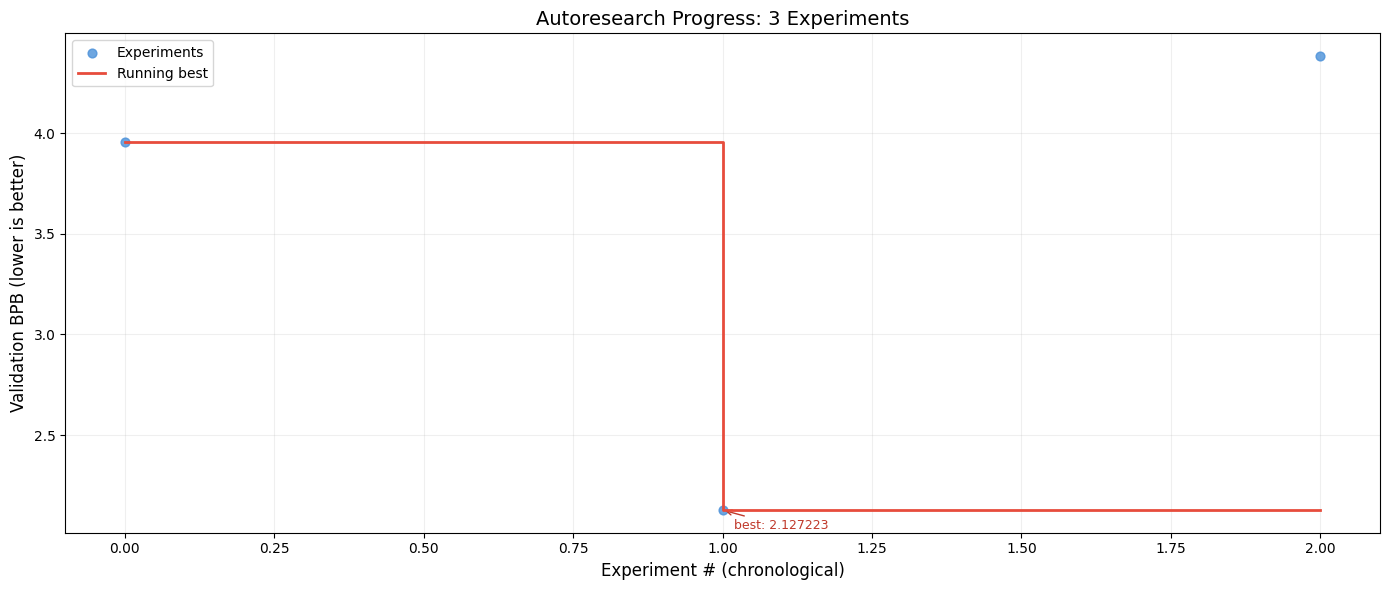

Saved to progress.png


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

x = df.index
y = df["val_bpb"]
running_min = y.cummin()

ax.scatter(x, y, c="#4a90d9", s=40, zorder=3, label="Experiments", alpha=0.8)
ax.step(x, running_min, where="post", color="#e74c3c", linewidth=2, zorder=4, label="Running best")

# Annotate the best run
best_idx = y.idxmin()
ax.annotate(f"best: {y[best_idx]:.6f}",
            (best_idx, y[best_idx]),
            textcoords="offset points", xytext=(8, -14),
            fontsize=9, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1))

ax.set_xlabel("Experiment # (chronological)", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {len(df)} Experiments", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [9]:
baseline_bpb = df.iloc[0]["val_bpb"]
best_bpb = df["val_bpb"].min()
best_row = df.loc[df["val_bpb"].idxmin()]

print(f"Baseline val_bpb:  {baseline_bpb:.6f}")
print(f"Best val_bpb:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best run at:       {str(best_row['timestamp'])[:19]}")
print(f"  training_seconds={best_row['training_seconds']:.0f}  tokens_M={best_row['total_tokens_M']:.1f}  steps={best_row['num_steps']:.0f}")

Baseline val_bpb:  3.954539
Best val_bpb:      2.127223
Total improvement: 1.827316 (46.21%)
Best run at:       2026-03-18 07:25:11
  training_seconds=302  tokens_M=7.4  steps=113


## Compute vs Quality

How does training time / token count relate to val_bpb?

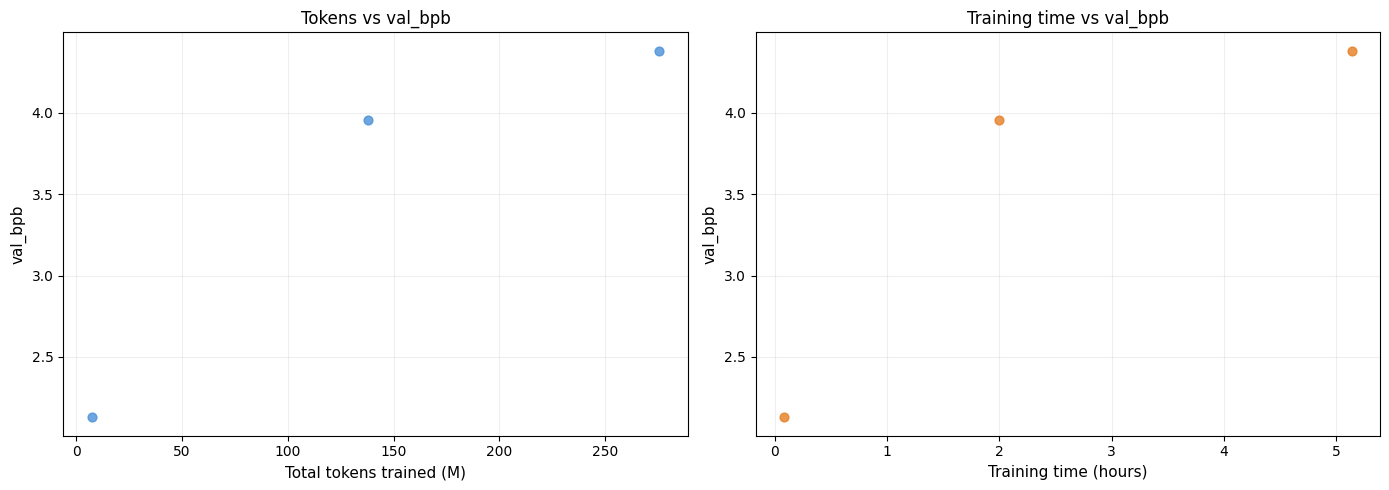

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["total_tokens_M"], df["val_bpb"], c="#4a90d9", s=40, alpha=0.8)
axes[0].set_xlabel("Total tokens trained (M)", fontsize=11)
axes[0].set_ylabel("val_bpb", fontsize=11)
axes[0].set_title("Tokens vs val_bpb", fontsize=12)
axes[0].grid(True, alpha=0.2)

axes[1].scatter(df["training_seconds"] / 3600, df["val_bpb"], c="#e67e22", s=40, alpha=0.8)
axes[1].set_xlabel("Training time (hours)", fontsize=11)
axes[1].set_ylabel("val_bpb", fontsize=11)
axes[1].set_title("Training time vs val_bpb", fontsize=12)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()